In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [81]:
df=pd.read_csv(r"C:\Users\HP\Desktop\Bacancy\AI_ML\Deep_Learning\NLP\Task1\tag1.csv")

- IT IS LEGAL DOCUMENT DATA WITH KEYWORDS 
- content → long legal text documents (French but badly encoded: C), C*, etc.)
- tags → legal topic labels like

In [3]:
df.drop(columns="Unnamed: 0",inplace=True)

In [ ]:
df

,content,keywords
0,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
1,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
2,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
3,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
4,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
...,...,...
752,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Prejudiciële bevoegheid (Grondwettelijk Hof)
753,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Prejudiciële bevoegheid (Grondwettelijk Hof)
754,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof)
755,"""Klagen auf vC6llige oder teilweise Nichtigerk...",Prejudiciële bevoegheid (Grondwettelijk Hof)


In [14]:
print(df.iloc[0].content)

"La Cour constitutionnelle,composC)e des prC)sidents F. DaoC;t et A. Alen, et des juges L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman et M. PC\"ques, assistC)e du greffier P.-Y. Dutilleux, prC)sidC)e par le prC)sident F. DaoC;t,aprC(s en avoir dC)libC)rC), rend l'arrC*t suivant :I. Objet du recours et procC)durePar requC*te adressC)e C  la Cour par lettre recommandC)e C  la poste le 5 avril 2017 et parvenue au greffe le 7 avril 2017, un recours en annulation des articles 24 C  27 de la loi-programme du 25 dC)cembre 2016 (Soins de santC) - Mesures conservatoires dans le cadre de la rC)forme des hC4pitaux), publiC)e au Moniteur belge du 29 dC)cembre 2016, deuxiC(me C)dition, a C)tC) introduit par l'ASBL B+ Santhea B; et la SCRL (intercommunale) B+ Centre hospitalier Universitaire et Psychiatrique de Mons-Borinage B;, assistC)es et reprC)sentC)es par Me E. Lemmens et Me E. Kiehl, avocats au barreau de LiC(ge, et Me P. L

In [15]:
print(df.iloc[0].keywords)

Vernietigingsbevoegdheid (Grondwettelijk Hof)


In [ ]:
# PYDANTIC + SQLALCHEMY  -> TOPICS SHOULD BE COVER
# SQL ALCHEMY -> USER BASE ROLE  ( HOW ROLE BASED SYSTEM HANDLES) (ACCESS MAANGEMENT) 
# MIGERATIONS IN SQL ALCHEMY  (ALEMBIC)


In [17]:
df["keywords"].value_counts()

keywords
Prejudiciële bevoegheid (Grondwettelijk Hof)     451
Vernietigingsbevoegdheid (Grondwettelijk Hof)    306
Name: count, dtype: int64

- Prejudiciële bevoegdheid (Grondwettelijk Hof):
When another court asks the Constitutional Court of Belgium whether a law is constitutional before deciding a case.

- Vernietigingsbevoegdheid (Grondwettelijk Hof):
When the Constitutional Court of Belgium directly reviews a law and can cancel (annul) it if it violates the constitution.

- Prejudiciële bevoegdheid → constitutional question from another court
- Vernietigingsbevoegdheid → request to annul a law


1. Prejudiciële bevoegdheid (Grondwettelijk Hof)

- If a normal court is handling a case and is unsure whether a law follows the constitution, it asks the Constitutional Court of Belgium for clarification before giving the final judgment.

Example:

A worker sues a company.

- The judge thinks the labor law used in the case might be unconstitutional.
- The judge asks the Constitutional Court: “Is this law valid under the constitution?”
- After the answer, the judge finishes the case.

👉 So here the Constitutional Court only answers a question.



2. Vernietigingsbevoegdheid (Grondwettelijk Hof)

- Here someone directly challenges a law, asking the Constitutional Court of Belgium to check it.
- If the court finds the law violates the constitution, it can remove (cancel) the law.

Example:

- The government passes a new tax law.
- A citizen group believes the law discriminates against them.
- They go directly to the Constitutional Court.

If the court agrees, the law is annulled.

👉 So here the Constitutional Court can delete the law from the legal system.
- Annul a law means to officially cancel a law so it is no longer valid or used.

- Yes — the data is very likely from Belgium.

Reasons:
- The terms “Grondwettelijk Hof” refer specifically to the Constitutional Court of Belgium.
- The language used (Dutch / Flemish) is one of the official languages of Belgium.
- Legal procedures like “Prejudiciële bevoegdheid” and “Vernietigingsbevoegdheid” are standard classifications used in decisions of that court.
- So your dataset probably contains Belgian constitutional court judgments (or summaries of them) labeled by type of constitutional procedure.

### APPLICATIONS 

- Legal document classification
- Automatic tagging of court judgments
- Legal search systems
- Legal Document Summarization
- Named Entity Recognition (NER)
- Topic Modeling
- Semantic Similarity / Case Recommendation
- Legal Question Answering

## Belgium Official Languages :
 -  Dutch (spoken by ~60%, mainly in the north/Flanders)
 -  French (spoken by ~33%, mainly in the south/Wallonia)
 -  German (spoken by ~1%, in the eastern cantons)

- Domain
Legal text.

- Style
Formal judicial language.

- Length
Usually long paragraphs.

-Noise
dataset has encoding problems:

In [12]:
import re

def clean_text(text, max_length=140):
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = re.sub(r"\\[a-zA-Z]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    if len(text) > max_length:
        text = text[:max_length].rsplit(" ", 1)[0].strip() + "..."

    return text

lines = []
i=0

for idx, (content, label) in enumerate(zip(df["content"], df["keywords"]), start=1):
    i+=1
    if i<=400:
        continue  
    processed_content = clean_text(content, max_length=140)
    row = f"{idx}. {processed_content} -> {label}"
    lines.append(row)
   


with open("sample2.txt", "w", encoding="utf-8") as file:
    file.write("\n".join(lines))

print("Saved cleaned samples to sample.txt")
print(lines[:5])

Saved cleaned samples to sample.txt
['401. 11/2018 NL B.5. Demzufolge ist die Sitzung unter Ausschluss der Öffentlichkeit abzuhalten. Aus diesen Gründen: Der Gerichtshof beschließt,... -> Prejudiciële bevoegheid (Grondwettelijk Hof)', '402. 9/2018 NL B.11.1. Cependant, la procédure dans l’affaire soumise à la juridiction a quo fait apparaître que, lorsque la Cour de cassation a... -> Prejudiciële bevoegheid (Grondwettelijk Hof)', '403. 10/2018 NL OFFICIELE BERICHTEN — AVIS OFFICIELS GRONDWETTELIJK HOF [2018/201863] Uittreksel uit arrest nr. 10/2018 van 1 februari 2018... -> Prejudiciële bevoegheid (Grondwettelijk Hof)', '404. 11/2018 NL B.5. Demzufolge ist die Sitzung unter Ausschluss der Öffentlichkeit abzuhalten. Aus diesen Gründen: Der Gerichtshof beschließt,... -> Prejudiciële bevoegheid (Grondwettelijk Hof)', '405. 4/2018 NL SERVICE PUBLIC DE WALLONIE [2018/202769] Direction générale opérationnelle Agriculture, Ressources naturelles et Environnement. —... -> Prejudiciële bevoeghei

In [6]:
with open("sample.txt","w") as f :
    f.write("h")

## PREPROCESSING STEPS 

In [13]:
## remove the duplicates 
print("TOTAL DUPLICATES:",df.duplicated().sum())
df = df.drop_duplicates(subset='content')
print(f"After dedup: {len(df)} records")

TOTAL DUPLICATES: 350
After dedup: 406 records


In [14]:
df

,content,keywords
0,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
1,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
2,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
3,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
4,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
...,...,...
627,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof)
628,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof)
629,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof)
630,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof)


In [16]:
df["keywords"].value_counts()

keywords
Prejudiciële bevoegheid (Grondwettelijk Hof)     258
Vernietigingsbevoegdheid (Grondwettelijk Hof)    148
Name: count, dtype: int64

## DETECT LANGUAGE FROM EACH DOCUMENT

In [17]:
from lingua import Language, LanguageDetectorBuilder

detector = LanguageDetectorBuilder.from_languages(
    Language.FRENCH, Language.DUTCH, Language.GERMAN
).build()

def detect_lang(text):
    result = detector.detect_language_of(text[:500])
    return result.name if result else "UNKNOWN"

df['language'] = df['content'].apply(detect_lang)
print(df['language'].value_counts())

language
DUTCH     149
FRENCH    135
GERMAN    122
Name: count, dtype: int64


In [20]:
content = df["content"].astype(str)
lengths = content.str.len()
tokens_est = lengths / 4.0

print(f"Total records (after dedup): {len(df)}")
print(f"Average text length: {lengths.mean():,.2f} characters")
print(f"Min text length: {lengths.min():,} characters")
print(f"Max text length: {lengths.max():,} characters")
print(f"Estimated avg tokens: {tokens_est.mean():,.2f} tokens")
print(f"Records < 512 tokens: {(tokens_est < 512).sum()} / {len(df)} ({(tokens_est < 512).mean()*100:.1f}%)")
print(f"Records > 512 tokens: {(tokens_est > 512).sum()} / {len(df)} ({(tokens_est > 512).mean()*100:.1f}%)")


Total records (after dedup): 406
Average text length: 21,943.15 characters
Min text length: 1,179 characters
Max text length: 65,535 characters
Estimated avg tokens: 5,485.79 tokens
Records < 512 tokens: 2 / 406 (0.5%)
Records > 512 tokens: 404 / 406 (99.5%)


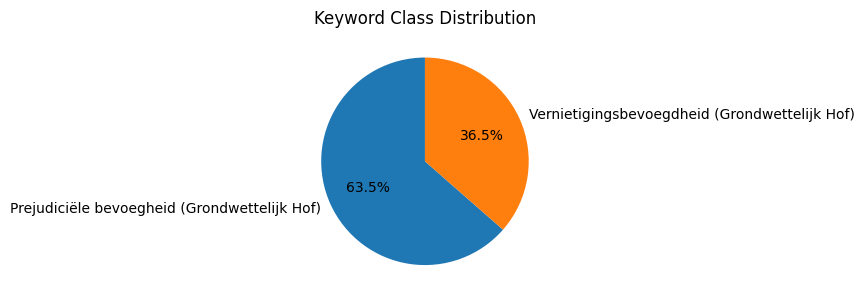

In [28]:

counts = df["keywords"].value_counts()

plt.figure(figsize=(8, 8))
counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Keyword Class Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [31]:
df1 = pd.read_csv("sample.csv", encoding="utf-8")   # try first
# or
# or
df3 = pd.read_csv("sample.csv", encoding="latin1")  # fallback


In [36]:
df

,content,keywords,language
0,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),FRENCH
1,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),DUTCH
2,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof),GERMAN
3,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),FRENCH
4,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),DUTCH
...,...,...,...
627,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),FRENCH
628,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),FRENCH
629,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof),GERMAN
630,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),FRENCH


In [37]:
df1

,Unnamed: 0,content,keywords
0,0,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
1,1,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
2,2,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
3,3,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
4,4,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
...,...,...,...
401,627,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof)
402,628,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof)
403,629,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof)
404,630,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof)


In [38]:
df3

,Unnamed: 0,content,keywords
0,0,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
1,1,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
2,2,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
3,3,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
4,4,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof)
...,...,...,...
401,627,"""La Cour constitutionnelle,composC)e des prC)s...",PrejudiciÃ«le bevoegheid (Grondwettelijk Hof)
402,628,"""La Cour constitutionnelle,composC)e des prC)s...",PrejudiciÃ«le bevoegheid (Grondwettelijk Hof)
403,629,"""Der Verfassungsgerichtshof,zusammengesetzt au...",PrejudiciÃ«le bevoegheid (Grondwettelijk Hof)
404,630,"""La Cour constitutionnelle,composC)e des prC)s...",PrejudiciÃ«le bevoegheid (Grondwettelijk Hof)


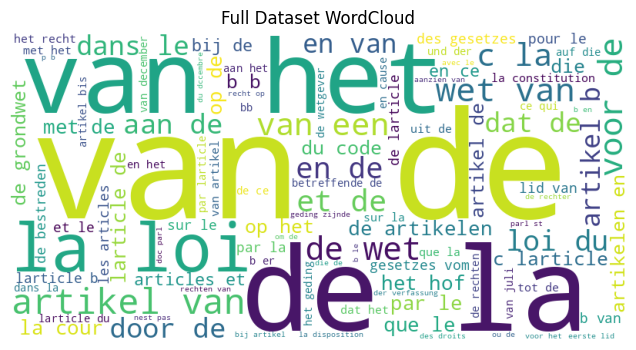

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re

df = pd.read_csv("sample.csv")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["clean_content"] = df["content"].apply(clean_text)

all_text = " ".join(df["clean_content"].tolist())

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(all_text)

plt.figure(figsize=(8,4))
plt.imshow(wc)
plt.axis("off")
plt.title("Full Dataset WordCloud")
plt.show()


## FULL PROCESSING PIPELINE 

In [91]:
import pandas as pd

df = pd.read_csv('sample.csv', index_col=0)

print(df.shape)         
print(df.columns)       
print(df['keywords'].value_counts())

(406, 2)
Index(['content', 'keywords'], dtype='str')
keywords
Prejudiciële bevoegheid (Grondwettelijk Hof)     258
Vernietigingsbevoegdheid (Grondwettelijk Hof)    148
Name: count, dtype: int64


In [92]:
content = df["content"].astype(str)
lengths = content.str.len()
tokens_est = lengths / 4.0

print(f"Total records (after dedup): {len(df)}")
print(f"Average text length: {lengths.mean():,.2f} characters")
print(f"Min text length: {lengths.min():,} characters")
print(f"Max text length: {lengths.max():,} characters")
print(f"Estimated avg tokens: {tokens_est.mean():,.2f} tokens")
print(f"Records < 512 tokens: {(tokens_est < 512).sum()} / {len(df)} ({(tokens_est < 512).mean()*100:.1f}%)")
print(f"Records > 512 tokens: {(tokens_est > 512).sum()} / {len(df)} ({(tokens_est > 512).mean()*100:.1f}%)")


Total records (after dedup): 406
Average text length: 21,943.15 characters
Min text length: 1,179 characters
Max text length: 65,535 characters
Estimated avg tokens: 5,485.79 tokens
Records < 512 tokens: 2 / 406 (0.5%)
Records > 512 tokens: 404 / 406 (99.5%)


In [93]:
import re

In [94]:
def clean_text(text):
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = re.sub(r"\\[a-zA-Z]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

 

    return text


df['content_clean'] = df['content'].apply(clean_text)


In [95]:
import ftfy

df['content_clean'] = df['content_clean'].apply(ftfy.fix_text)

sample = df['content_clean'].iloc[0][:200]
print(sample)

"La Cour constitutionnelle,composC)e des prC)sidents F. DaoC;t et A. Alen, et des juges L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moer


In [96]:
from lingua import Language, LanguageDetectorBuilder

detector = LanguageDetectorBuilder.from_languages(
    Language.FRENCH, Language.DUTCH, Language.GERMAN
).build()

def detect_lang(text):
    result = detector.detect_language_of(text[:500])
    return result.name if result else "UNKNOWN"

df['language'] = df['content_clean'].apply(detect_lang)
print(df['language'].value_counts())

language
DUTCH     150
FRENCH    134
GERMAN    122
Name: count, dtype: int64


In [97]:
content = df["content_clean"].astype(str)
lengths = content.str.len()
tokens_est = lengths / 4.0

print(f"Total records (after dedup): {len(df)}")
print(f"Average text length: {lengths.mean():,.2f} characters")
print(f"Min text length: {lengths.min():,} characters")
print(f"Max text length: {lengths.max():,} characters")
print(f"Estimated avg tokens: {tokens_est.mean():,.2f} tokens")
print(f"Records < 512 tokens: {(tokens_est < 512).sum()} / {len(df)} ({(tokens_est < 512).mean()*100:.1f}%)")
print(f"Records > 512 tokens: {(tokens_est > 512).sum()} / {len(df)} ({(tokens_est > 512).mean()*100:.1f}%)")


Total records (after dedup): 406
Average text length: 21,885.68 characters
Min text length: 1,176 characters
Max text length: 65,535 characters
Estimated avg tokens: 5,471.42 tokens
Records < 512 tokens: 2 / 406 (0.5%)
Records > 512 tokens: 404 / 406 (99.5%)


| Language | Phrase                                                          | Meaning in English                                   |
| -------- | --------------------------------------------------------------- | ---------------------------------------------------- |
| French   | La Cour constitutionnelle,composC)e des prC)sidents             | The Constitutional Court, composed of the presidents |
| Dutch    | Het Grondwettelijk Hof,samengesteld uit de voorzitters          | The Constitutional Court, composed of the presidents |
| German   | Der Verfassungsgerichtshof,zusammengesetzt aus den PrC$sidenten | The Constitutional Court, composed of the presidents |


In [98]:
df[df["language"]=="GERMAN"]["content_clean"].tolist()

['"Der Verfassungsgerichtshof,zusammengesetzt aus den PrC$sidenten F. DaoC;t und A. Alen, und den Richtern L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman und M. PC\\"ques, unter Assistenz des Kanzlers P.-Y. Dutilleux, unter dem Vorsitz des PrC$sidenten F. DaoC;t,erlC$sst nach Beratung folgenden Entscheid:I. Gegenstand der Klage und VerfahrenMit einer Klageschrift, die dem Gerichtshof mit am 5. April 2017 bei der Post aufgegebenem Einschreibebrief zugesandt wurde und am 7. April 2017 in der Kanzlei eingegangen ist, erhoben Klage auf NichtigerklC$rung der Artikel 24 bis 27 des Programmgesetzes vom 25. Dezember 2016 (Gesundheitspflege - SicherungsmaC 001fnahmen im Rahmen der Krankenhausreform), verC6ffentlicht im Belgischen Staatsblatt vom 29. Dezember 2016: die VoG B+ Santhea B; und die B+ Centre hospitalier Universitaire et Psychiatrique de Mons-Borinage B; (interkommunale) Gen.mbH, unterstC(...)II. Rechtliche WC(...)B

In [99]:
print("ONE STATEMENT OF FRENCH LANGUAGE",df[df["language"]=="FRENCH"]["content"].iloc[0])
print("SECOND STATEMENT OF FRENCH LANGUAGE",df[df["language"]=="FRENCH"]["content"].iloc[1])
print("THIRD STATEMENT OF FRENCH LANGUAGE",df[df["language"]=="FRENCH"]["content"].iloc[2])



ONE STATEMENT OF FRENCH LANGUAGE "La Cour constitutionnelle,composC)e des prC)sidents F. DaoC;t et A. Alen, et des juges L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman et M. PC\"ques, assistC)e du greffier P.-Y. Dutilleux, prC)sidC)e par le prC)sident F. DaoC;t,aprC(s en avoir dC)libC)rC), rend l'arrC*t suivant :I. Objet du recours et procC)durePar requC*te adressC)e C  la Cour par lettre recommandC)e C  la poste le 5 avril 2017 et parvenue au greffe le 7 avril 2017, un recours en annulation des articles 24 C  27 de la loi-programme du 25 dC)cembre 2016 (Soins de santC) - Mesures conservatoires dans le cadre de la rC)forme des hC4pitaux), publiC)e au Moniteur belge du 29 dC)cembre 2016, deuxiC(me C)dition, a C)tC) introduit par l'ASBL B+ Santhea B; et la SCRL (intercommunale) B+ Centre hospitalier Universitaire et Psychiatrique de Mons-Borinage B;, assistC)es et reprC)sentC)es par Me E. Lemmens et Me E. Kiehl, avocats

In [100]:
boilerplate_phrases = [
    "Het Grondwettelijk Hof,samengesteld uit de voorzitters",
    "La Cour constitutionnelle,composC)e des prC)sidents",
    "Der Verfassungsgerichtshof,zusammengesetzt aus den PrC$sidenten"
]

def clean_text(text):
    for phrase in boilerplate_phrases:
        text = text.replace(phrase, "")
    return text

df['content_clean'] = df['content'].apply(clean_text)


In [101]:
df[df["language"]=="GERMAN"]["content_clean"].tolist()

['" F. DaoC;t und A. Alen, und den Richtern L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman und M. PC\\"ques, unter Assistenz des Kanzlers P.-Y. Dutilleux, unter dem Vorsitz des PrC$sidenten F. DaoC;t,erlC$sst nach Beratung folgenden Entscheid:I. Gegenstand der Klage und VerfahrenMit einer Klageschrift, die dem Gerichtshof mit am 5. April 2017 bei der Post aufgegebenem Einschreibebrief zugesandt wurde und am 7. April 2017 in der Kanzlei eingegangen ist, erhoben Klage auf NichtigerklC$rung der Artikel 24 bis 27 des Programmgesetzes vom 25. Dezember 2016 (Gesundheitspflege - SicherungsmaC\\u001fnahmen im Rahmen der Krankenhausreform), verC6ffentlicht im Belgischen Staatsblatt vom 29. Dezember 2016: die VoG B+ Santhea B; und die B+ Centre hospitalier Universitaire et Psychiatrique de Mons-Borinage B; (interkommunale) Gen.mbH, unterstC(...)II. Rechtliche WC(...)B.1.1. Die Artikel 24 bis 27 des Programmgesetzes vom 25. Deze

In [102]:
df

,content,keywords,content_clean,language
0,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),""" F. DaoC;t et A. Alen, et des juges L. Lavrys...",FRENCH
1,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),""" F. DaoC;t en A. Alen, en de rechters L. Lavr...",DUTCH
2,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof),""" F. DaoC;t und A. Alen, und den Richtern L. L...",GERMAN
3,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),""" F. DaoC;t et A. Alen, et des juges L. Lavrys...",FRENCH
4,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),""" F. DaoC;t en A. Alen, en de rechters L. Lavr...",DUTCH
...,...,...,...,...
627,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),""" J. Spreutels et E. De Groot, et des juges L....",FRENCH
628,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),""" E. De Groot et J. Spreutels, et des juges L....",FRENCH
629,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof),""" E. De Groot und J. Spreutels, und den Richte...",GERMAN
630,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),""" E. De Groot et J. Spreutels, et des juges L....",FRENCH


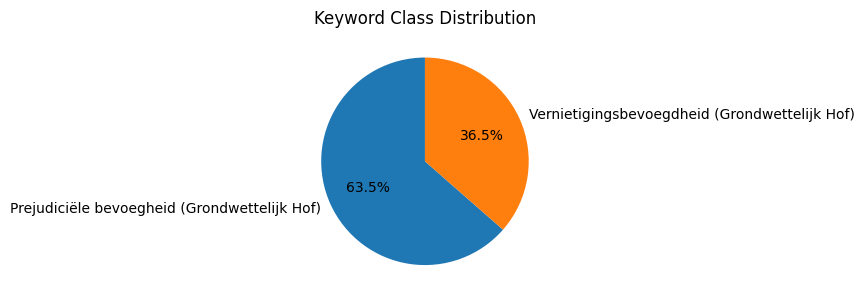

In [62]:

counts = df["keywords"].value_counts()

plt.figure(figsize=(8, 8))
counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Keyword Class Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [63]:
print(df['content_clean'].iloc[0][:300])

" F. DaoC;t et A. Alen, et des juges L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman et M. PC\"ques, assistC)e du greffier P.-Y. Dutilleux, prC)sidC)e par le prC)sident F. DaoC;t,aprC(s en avoir dC)libC)rC), rend l'arrC*t suivant :I


In [ ]:
def fix_encoding_artifacts(text):
    result = []
    i = 0
    text = str(text)
    while i < len(text):
        if text[i] == 'C' and i + 1 < len(text):
            next_char = text[i + 1]
            code = ord(next_char) + 0xC0
            if 0xC0 <= code <= 0xFF:
                result.append(chr(code))
                i += 2
                continue
        result.append(text[i])
        i += 1
    return "".join(result)

df['content_clean'] = df['content_clean'].apply(fix_encoding_artifacts)

# verify
print(df['content_clean'].iloc[0][:300])

" F. Daoût et A. Alen, et des juges L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman et M. PC\"ques, assistée du greffier P.-Y. Dutilleux, présidée par le président F. Daoût,après en avoir délibéré, rend l'arrêt suivant :I. Objet du 


In [65]:
import re

def final_clean(text):
    text = str(text)
    text = text.strip('"').strip("'")
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['content_clean'] = df['content_clean'].apply(final_clean)
print(df['content_clean'].iloc[0][:300])

F. Daoût et A. Alen, et des juges L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman et M. PC\"ques, assistée du greffier P.-Y. Dutilleux, présidée par le président F. Daoût,après en avoir délibéré, rend l'arrêt suivant :I. Objet du re


In [66]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("Max sequence length:", model.max_seq_length)  
print("Embedding dim:", model.get_sentence_embedding_dimension()) 

c:\Users\HP\Desktop\Bacancy\AI_ML\Deep_Learning\dl_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\HP\Desktop\Bacancy\AI_ML\Deep_Learning\dl_env\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Devel

Max sequence length: 128
Embedding dim: 384


In [67]:
def chunk_text(text, chunk_size=100, overlap=20):
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunks.append(" ".join(words[start:end]))
        if end == len(words):
            break
        start += chunk_size - overlap 
    return chunks

# preview
sample_chunks = chunk_text(df['content_clean'].iloc[0])
print(f"Document word count : {len(df['content_clean'].iloc[0].split())}")
print(f"Number of chunks    : {len(sample_chunks)}")
print(f"First chunk         : {sample_chunks[0][:150]}")

Document word count : 4688
Number of chunks    : 59
First chunk         : F. Daoût et A. Alen, et des juges L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman 


In [68]:
import numpy as np
from tqdm import tqdm

def embed_document(text, model, chunk_size=100, overlap=20):
    chunks = chunk_text(text, chunk_size, overlap)
    chunk_embeddings = model.encode(chunks, batch_size=32, show_progress_bar=False)
    return np.mean(chunk_embeddings, axis=0)

embeddings = []

for text in tqdm(df['content_clean'], desc="Embedding documents"):
    emb = embed_document(text, model)
    embeddings.append(emb)

embeddings = np.array(embeddings)
print("Embeddings shape:", embeddings.shape)  # (406, 384)

Embedding documents: 100%|██████████| 406/406 [22:04<00:00,  3.26s/it]

Embeddings shape: (406, 384)


In [ ]:

np.save("Output/document_embeddings.npy", embeddings)


df['embedding_idx'] = range(len(df))
df[['content_clean', 'keywords', 'language', 'embedding_idx']].to_csv("Output/df_with_idx.csv", index=False)

print("Saved embeddings:", embeddings.shape)
print(df[['keywords', 'language']].value_counts())

Saved embeddings: (406, 384)
keywords                                       language
Prejudiciële bevoegheid (Grondwettelijk Hof)   DUTCH       91
                                               FRENCH      87
                                               GERMAN      80
Vernietigingsbevoegdheid (Grondwettelijk Hof)  DUTCH       59
                                               FRENCH      47
                                               GERMAN      42
Name: count, dtype: int64


In [79]:
from sklearn.metrics.pairwise import cosine_similarity

french_idx = df[df['language'] == 'FRENCH'].index[40]
dutch_idx  = df[df['language'] == 'DUTCH'].index[40]
german_idx = df[df['language'] == 'GERMAN'].index[40]

sim_fr_nl = cosine_similarity([embeddings[french_idx]], [embeddings[dutch_idx]])[0][0]
sim_fr_de = cosine_similarity([embeddings[french_idx]], [embeddings[german_idx]])[0][0]

print(f"Similarity French ↔ Dutch  (same class): {sim_fr_nl:.4f}")
print(f"Similarity French ↔ German (same class): {sim_fr_de:.4f}")

Similarity French ↔ Dutch  (same class): 0.8769
Similarity French ↔ German (same class): 0.7172


In [ ]:
df[df['language'] == 'FRENCH'].index[]

np.int64(0)

In [72]:
df

,content,keywords,content_clean,language,embedding_idx
0,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"F. Daoût et A. Alen, et des juges L. Lavrysen,...",FRENCH,0
1,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"F. Daoût en A. Alen, en de rechters L. Lavryse...",DUTCH,1
2,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"F. Daoût und A. Alen, und den Richtern L. Lavr...",GERMAN,2
3,"""La Cour constitutionnelle,composC)e des prC)s...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"F. Daoût et A. Alen, et des juges L. Lavrysen,...",FRENCH,3
4,"""Het Grondwettelijk Hof,samengesteld uit de vo...",Vernietigingsbevoegdheid (Grondwettelijk Hof),"F. Daoût en A. Alen, en de rechters L. Lavryse...",DUTCH,4
...,...,...,...,...,...
627,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),"J. Spreutels et E. De Groot, et des juges L. L...",FRENCH,401
628,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),"E. De Groot et J. Spreutels, et des juges L. L...",FRENCH,402
629,"""Der Verfassungsgerichtshof,zusammengesetzt au...",Prejudiciële bevoegheid (Grondwettelijk Hof),"E. De Groot und J. Spreutels, und den Richtern...",GERMAN,403
630,"""La Cour constitutionnelle,composC)e des prC)s...",Prejudiciële bevoegheid (Grondwettelijk Hof),"E. De Groot et J. Spreutels, et des juges L. L...",FRENCH,404


In [73]:
french_idx = df[df['language'] == 'FRENCH'].index[0]
dutch_idx  = df[df['language'] == 'DUTCH'].index[0]
german_idx = df[df['language'] == 'GERMAN'].index[0]

print("=== FRENCH DOC ===")
print(df.loc[french_idx, 'content_clean'][:500])
print()
print("=== DUTCH DOC ===")
print(df.loc[dutch_idx, 'content_clean'][:500])
print()
print("=== GERMAN DOC ===")
print(df.loc[german_idx, 'content_clean'][:500])

=== FRENCH DOC ===
F. Daoût et A. Alen, et des juges L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman et M. PC\"ques, assistée du greffier P.-Y. Dutilleux, présidée par le président F. Daoût,après en avoir délibéré, rend l'arrêt suivant :I. Objet du recours et procédurePar requête adressée à la Cour par lettre recommandée à la poste le 5 avril 2017 et parvenue au greffe le 7 avril 2017, un recours en annulation des articles 24 à 27 de la loi-progra

=== DUTCH DOC ===
F. Daoût en A. Alen, en de rechters L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman en M. PC\"ques, bijgestaan door de griffier P.-Y. Dutilleux, onder voorzitterschap van voorzitter F. Daoût,wijst na beraad het volgende arrest :I. Onderwerp van het beroep en rechtsplegingBij verzoekschrift dat aan het Hof is toegezonden bij op 5 april 2017 ter post aangetekende brief en ter griffie is ingek

In [77]:
df[df['language'] == 'DUTCH']["content"].iloc[0]

'"Het Grondwettelijk Hof,samengesteld uit de voorzitters F. DaoC;t en A. Alen, en de rechters L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman en M. PC\\"ques, bijgestaan door de griffier P.-Y. Dutilleux, onder voorzitterschap van voorzitter F. DaoC;t,wijst na beraad het volgende arrest :I. Onderwerp van het beroep en rechtsplegingBij verzoekschrift dat aan het Hof is toegezonden bij op 5 april 2017 ter post aangetekende brief en ter griffie is ingekomen op 7 april 2017, is beroep tot vernietiging ingesteld van de artikelen 24 tot 27 van de programmawet van 25 december 2016 (Gezondheidszorg - Bewarende maatregelen in het kader van ziekenhuishervorming), bekendgemaakt in het Belgisch Staatsblad van 29 december 2016, tweede editie, door de vzw B+ Santhea B; en de (intercommunale) cvba B+ Centre hospitalier Universitaire et Psychiatrique de Mons-Borinage B;, bijgestaan en vertegenwoordigd door Mr. E. Lemmens en Mr. E. Kieh

### **FRENCH DOC (Translated)**

> F. Daoût and A. Alen, and the judges L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman, and M. PC"ques, assisted by the clerk P.-Y. Dutilleux, presided over by President F. Daoût, after deliberation, delivers the following judgment:
> **I. Subject of the appeal and procedure**
> By a petition sent to the Court by registered mail on April 5, 2017, and received at the registry on April 7, 2017, an appeal for annulment of Articles 24 to 27 of the program law…

---

### **DUTCH DOC (Translated)**

> F. Daoût and A. Alen, and the judges L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman, and M. PC"ques, assisted by the clerk P.-Y. Dutilleux, under the chairmanship of President F. Daoût, after deliberation, delivers the following judgment:
> **I. Subject of the appeal and legal procedure**
> By a petition sent to the Court by registered letter on April 5, 2017, and received at the registry on April 7, 2017, an appeal for…

---

### **GERMAN DOC (Translated)**

> F. Daoût and A. Alen, and the judges L. Lavrysen, J.-P. Snappe, J.-P. Moerman, E. Derycke, T. Merckx-Van Goey, P. Nihoul, T. Giet, R. Leysen, J. Moerman, and M. PC"ques, assisted by the clerk P.-Y. Dutilleux, under the chairmanship of President F. Daoût, issues, after consultation, the following decision:
> **I. Subject of the complaint and procedure**
> With a petition sent to the Court by registered letter posted on April 5, 2017, and received at the registry on April 7, 2017, a complaint for…

---

## MODEL TRAINING 

In [88]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

le = LabelEncoder()
y = le.fit_transform(df['keywords'])   # 0 or 1

print("Classes:", le.classes_)
print("Label distribution:", np.bincount(y))

Classes: ['Prejudiciële bevoegheid (Grondwettelijk Hof)'
 'Vernietigingsbevoegdheid (Grondwettelijk Hof)']
Label distribution: [258 148]


In [89]:
y.shape

(406,)

In [108]:
import tensorflow as tf

X_emb = embeddings  

X_emb_train, X_emb_test, y_emb_train, y_emb_test = train_test_split(
    X_emb, y, test_size=0.2, random_state=42, stratify=y
)

model_emb = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(384,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_emb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_emb.summary()

history_emb = model_emb.fit(
    X_emb_train, y_emb_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

loss, acc = model_emb.evaluate(X_emb_test, y_emb_test)
print(f"\nModel 1 (Embeddings) → Test Accuracy: {acc:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,585 (514.00 KB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6117 - loss: 0.6390 - val_accuracy: 0.6970 - val_loss: 0.5674
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6667 - loss: 0.5761 - val_accuracy: 0.6970 - val_loss: 0.5195
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7320 - loss: 0.5134 - val_accuracy: 0.7273 - val_loss: 0.4760
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7973 - loss: 0.4668 - val_accuracy: 0.6970 - val_loss: 0.4911
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7973 - loss: 0.4188 - val_accuracy: 0.7273 - val_loss: 0.4744
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8041 - loss: 0.3831 - val_accuracy: 0.8182 - val_loss: 0.3743
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8729 - loss: 0.3391 - val_accuracy: 0.8182 - val_loss: 0.3675
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9038 - loss: 0.2797 - val_accuracy: 0.8182 - v

## WITHOUT EMBEDDING

In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

X_text = df['content_clean'].astype(str).values

X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True      
)

X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf  = tfidf.transform(X_text_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape (test) :", X_test_tfidf.shape)

TF-IDF matrix shape (train): (324, 20000)
TF-IDF matrix shape (test) : (82, 20000)


In [104]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_text_train)

y_pred_lr = lr.predict(X_test_tfidf)
acc_lr = accuracy_score(y_text_test, y_pred_lr)

print(f"Logistic Regression → Test Accuracy: {acc_lr:.4f}")
print(classification_report(y_text_test, y_pred_lr, target_names=le.classes_))

Logistic Regression → Test Accuracy: 0.9268
                                               precision    recall  f1-score   support

 Prejudiciële bevoegheid (Grondwettelijk Hof)       0.90      1.00      0.95        52
Vernietigingsbevoegdheid (Grondwettelijk Hof)       1.00      0.80      0.89        30

                                     accuracy                           0.93        82
                                    macro avg       0.95      0.90      0.92        82
                                 weighted avg       0.93      0.93      0.92        82



In [ ]:
svm = SVC(kernel='linear', C=1.0, random_state=42)
svm.fit(X_train_tfidf, y_text_train)

y_pred_svm = svm.predict(X_test_tfidf)
acc_svm = accuracy_score(y_text_test, y_pred_svm)

print(f"SVM (linear kernel) → Test Accuracy: {acc_svm:.4f}")
print(classification_report(y_text_test, y_pred_svm, target_names=le.classes_))

SVM (linear kernel) → Test Accuracy: 0.9390
                                               precision    recall  f1-score   support

 Prejudiciële bevoegheid (Grondwettelijk Hof)       0.94      0.96      0.95        52
Vernietigingsbevoegdheid (Grondwettelijk Hof)       0.93      0.90      0.92        30

                                     accuracy                           0.94        82
                                    macro avg       0.94      0.93      0.93        82
                                 weighted avg       0.94      0.94      0.94        82



In [109]:
# ── FINAL COMPARISON ──────────────────────────────────────────────────
print("=" * 45)
print(f"Model 1  — Embedding + DNN       : {acc:.4f}")
print(f"Model 2a — TF-IDF + Logistic Reg : {acc_lr:.4f}")
print(f"Model 2b — TF-IDF + SVM          : {acc_svm:.4f}")
print("=" * 45)

Model 1  — Embedding + DNN       : 0.9146
Model 2a — TF-IDF + Logistic Reg : 0.9268
Model 2b — TF-IDF + SVM          : 0.9390
